# Анализ розничных продаж продуктового ритейла

Импорт необходимых библиотек и настройка окружения.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', 100)

**Загрузка данных**

In [3]:
orders = pd.read_excel('../data/orders.xlsx')
orders.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74


In [4]:
products = pd.read_excel('../data/products.xlsx')
products.head(1)

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...


**Слияние таблиц по product_id (INNER JOIN)**

In [5]:
df = orders.merge(products, on='product_id', how='inner', suffixes=('_o', '_p'))
df.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан


##Самая ходовая товарная группа
Определим категорию товаров с максимальным объемом продаж в штуках.

In [6]:
d1 = df.groupby('level1').agg(count = ('quantity', 'sum')).reset_index()
d1 = d1.sort_values('count', ascending=False)
d1

,level1,count
1,Безалкогольные напитки,534
11,Молочная продукция,483
19,Свежие овощи,262
10,Кулинария,250
0,Бакалея,239
25,Хлеб и хлебобулочные изделия,218
21,Снэки,212
20,Свежие фрукты,184
6,Замороженная продукция,175
7,Кондитерские изделия,138


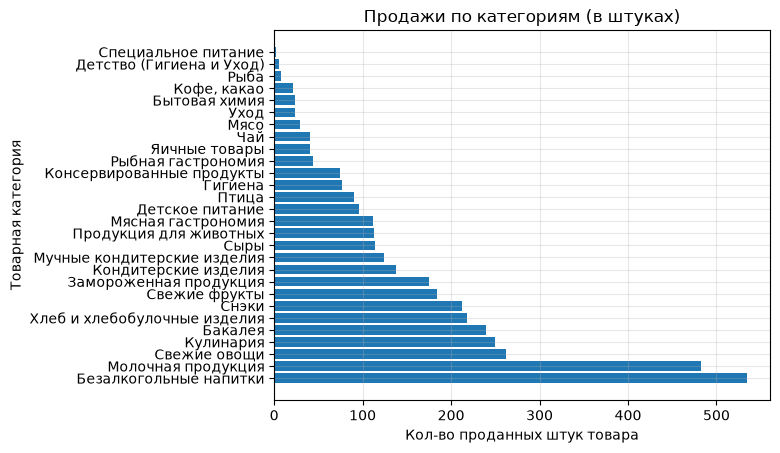

In [7]:
plt.barh(d1['level1'], d1['count'])

plt.ylabel('Товарная категория')
plt.xlabel('Кол-во проданных штук товара')
plt.title('Продажи по категориям (в штуках)')

plt.grid(alpha=0.3)

###Вывод
Самая популярная категория — **"Безалкогольные напитки"** с 534 проданными штуками.

##Распределение продаж по подкатегориям

In [8]:
d2 = df.groupby(['level1', 'level2']).agg(count = ('quantity', 'sum')).reset_index()
d2

,level1,level2,count
0,Бакалея,Все для суши,9
1,Бакалея,Зерновые для завтраков,24
2,Бакалея,Ингредиенты для готовки,21
3,Бакалея,"Крупы, бобовые",30
4,Бакалея,Макаронные изделия,24
5,Бакалея,Мука и мучные смеси,19
6,Бакалея,Пряности,21
7,Бакалея,Растительные масла,18
8,Бакалея,Сахар,11
9,Бакалея,Соусы,24


##Средний чек в заданную дату (13.01.2022)

In [9]:
orders_dt = orders[pd.to_datetime(orders['accepted_at']).dt.strftime('%d.%m.%Y') == '13.01.2022']
orders_dt.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74


In [10]:
orders_dt = orders_dt.groupby('order_id').apply(lambda x: pd.Series({'total_revenue': sum(x['quantity'] * x['price'])}), include_groups=False).reset_index()

In [11]:
mean_check = orders_dt['total_revenue'].mean()
mean_check

np.float64(915.6378676470588)

###Вывод
Средний чек 13.01.2022 составил ~ **915.64 руб.**

##Доля промо в категории "Сыры"

In [12]:
d_promo = df[df['level1'] == 'Сыры']
d_promo.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат


In [13]:
d_promo = d_promo[['quantity', 'regular_price', 'price']]
d_promo['is_promo'] = np.where(d_promo['regular_price'] > d_promo['price'], 'Промо-акция', 'Без акции')
d_promo.head(1)

,quantity,regular_price,price,is_promo
3,1,219,219,Без акции


In [14]:
d_promo = d_promo.groupby('is_promo').agg(count_products = ('quantity', 'sum')).reset_index()
d_promo['percent'] = d_promo['count_products'] / sum(d_promo['count_products'])
d_promo

,is_promo,count_products,percent
0,Без акции,79,0.692982
1,Промо-акция,35,0.307018


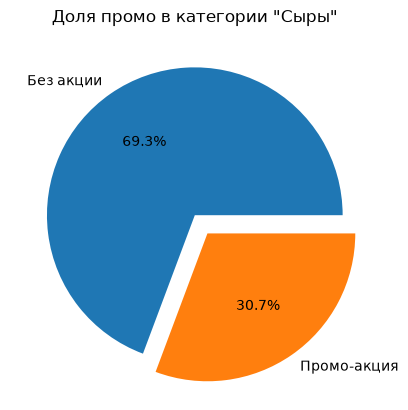

In [15]:
plt.pie(d_promo['count_products'], labels=d_promo['is_promo'], explode=[0, 0.15], autopct='%1.1f%%');

plt.title('Доля промо в категории "Сыры"');

###Вывод
Промо-продажи в категории "Сыры" составляют **30.7%** от общего объема.

##Маржа по категориям

In [16]:
d_margin = df.groupby('level1').apply(lambda x: pd.Series({'margin_rubles': sum(x['quantity'] * (x['price'] - x['cost_price'])), 'margin_%': sum(x['quantity'] * (x['price'] - x['cost_price'])) / sum(x['quantity'] * x['price']) * 100}), include_groups=False).reset_index()
d_margin

,level1,margin_rubles,margin_%
0,Бакалея,8177.0,37.567766
1,Безалкогольные напитки,20373.0,44.186349
2,Бытовая химия,1441.0,26.305221
3,Гигиена,2971.0,29.547489
4,Детское питание,1817.0,35.690434
5,Детство (Гигиена и Уход),517.0,29.901677
6,Замороженная продукция,13099.0,47.264920
7,Кондитерские изделия,5918.0,42.447282
8,Консервированные продукты,4154.0,41.124641
9,"Кофе, какао",5059.0,51.828706


In [17]:
d_margin_r = d_margin.sort_values('margin_rubles', ascending=False)
d_margin_p = d_margin.sort_values('margin_%', ascending=False)

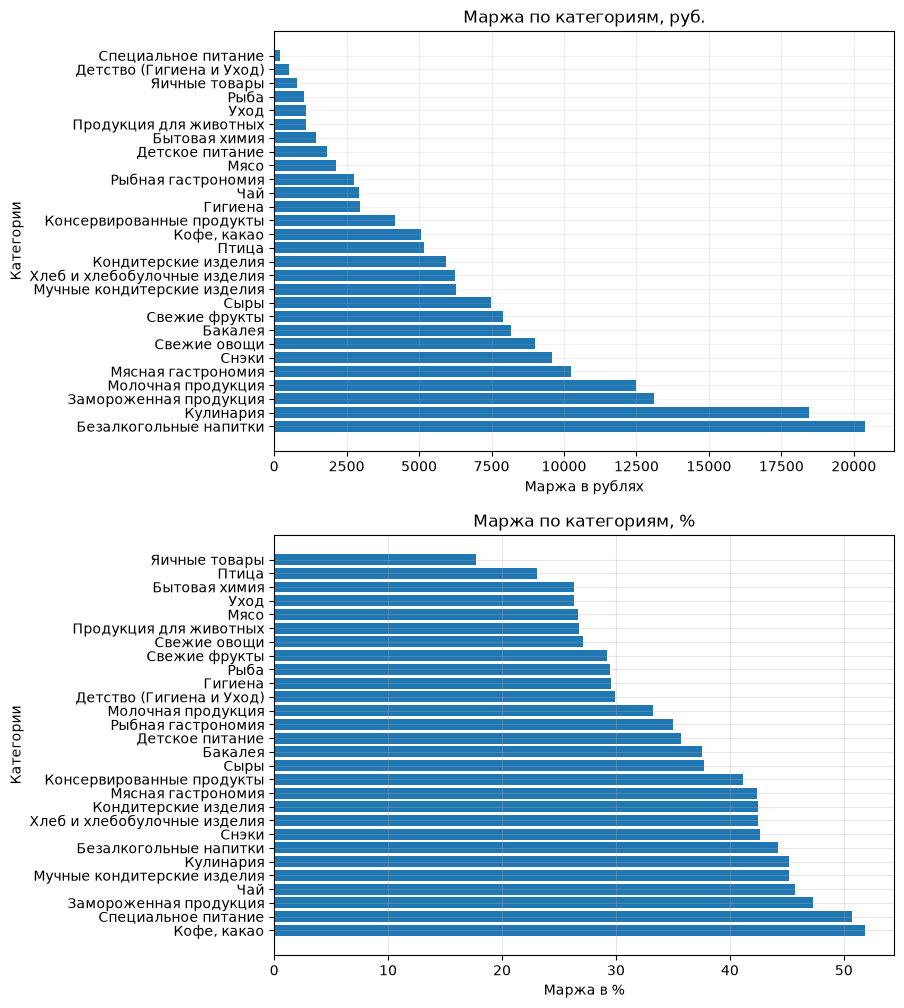

In [18]:
plt.rcParams['figure.figsize'] = (8, 12)

fig, ax = plt.subplots(2, 1)

ax[0].barh(d_margin_r['level1'], d_margin_r['margin_rubles'])
ax[1].barh(d_margin_p['level1'], d_margin_p['margin_%'])

ax[0].set_title('Маржа по категориям, руб.')
ax[0].set_xlabel('Маржа в рублях')
ax[0].set_ylabel('Категории')
ax[0].grid(alpha=0.2)

ax[1].set_title('Маржа по категориям, %')
ax[1].set_xlabel('Маржа в %')
ax[1].set_ylabel('Категории')
ax[1].grid(alpha=0.3)

###Вывод
**Маржа в рублях:**
- Лидер: **Безалкогольные напитки** (20373 руб.)
- Аутсайдер: **Специальное питание** (208 руб.)

**Маржа в %:**
- Лидер: **Кофе, какао** (~51.8%)
- Аутсайдер: **Яичные товары** (~17.7%)

##ABC анализ по подкатегориям (по количеству и по сумме продаж)

In [19]:
d_abc = df.groupby('level2').apply(lambda x: pd.Series({
        'price': (x['price'] * x['quantity']).sum(),
        'quantity': x['quantity'].sum()
    }), include_groups=False).reset_index()
d_abc.head(1)

,level2,price,quantity
0,"Бананы, косточковые и прочие плоды",10191,76


In [20]:
d_abc['rel_q'] = d_abc['quantity'] / sum(d_abc['quantity'])
d_abc['rel_p'] = d_abc['price'] / sum(d_abc['price'])
d_abc.head(1)

,level2,price,quantity,rel_q,rel_p
0,"Бананы, косточковые и прочие плоды",10191,76,0.020364,0.022809


In [21]:
d_abc = d_abc.sort_values('rel_q', ascending=False)
d_abc['cumsum_q'] = d_abc['rel_q'].cumsum()
d_abc['abc_q'] = np.where(d_abc['cumsum_q'] < 0.8, 'A', np.where(d_abc['cumsum_q'] < 0.95, 'B', 'C'))

In [22]:
d_abc = d_abc.sort_values('rel_p', ascending=False)
d_abc['cumsum_p'] = d_abc['rel_p'].cumsum()
d_abc['abc_p'] = np.where(d_abc['cumsum_p'] < 0.8, 'A', np.where(d_abc['cumsum_p'] < 0.95, 'B', 'C'))

In [23]:
d_abc['abc'] = d_abc['abc_p'] + ' ' + d_abc['abc_q']
d_abc[['level2', 'abc']].sort_values('abc')

,level2,abc
10,Готовые блюда,A A
3,Бумажная продукция,A A
73,Современные кондитерские изделия,A A
41,Молочно-десертные продукты,A A
43,Мороженое,A A
48,Мягкие сыры,A A
26,Кисломолочные традиционные продукты,A A
6,Воды питьевые,A A
74,Соковая продукция,A A
99,Яйцо куриное,A A


###Вывод
- В группу лидеров (**AA**) вошли основные товары повседневного спроса: молочная продукция, мясо, хлеб, овощи, фрукты и напитки. Именно эти категории формируют основную выручку и должны быть в приоритете с точки зрения наличия и продвижения.
- В группе аутсайдеров (**CC**) оказались товары гигиены, бытовая химия, икра и др. Рекомендуется рассмотреть возможность замены или вывода части товаров.